
VIDEO-LEVEL METRICS:
ROC-AUC = 0.6961
Average Precision (AP) = 0.4312


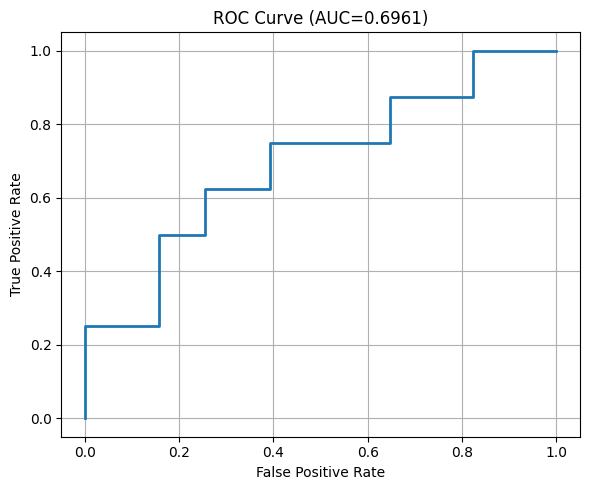

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import average_precision_score

from model import WSAD
from dataset_loader import FeatureDataset


# ======================================================================
# Inference Function
# ======================================================================
def run_inference(model, test_loader):
    model.eval()
    model.flag = "Test"

    video_scores = []
    video_labels = []
    snippet_scores_dict = {}

    with torch.no_grad():
        for data, label, name in test_loader:
            # data: [1, num_segments, feature_dim]
            label = int(label.item())
            name = name[0] if isinstance(name, (list, tuple)) else str(name)
            data = data.cuda()

            out = model(data)
            snippet_scores = out["frame"].squeeze().cpu().numpy()

            snippet_scores_dict[name] = snippet_scores
            video_scores.append(snippet_scores.max())
            video_labels.append(label)

    return video_scores, video_labels, snippet_scores_dict


# ======================================================================
# Metrics + Plots
# ======================================================================
def evaluate_and_plot(video_scores, video_labels):
    # os.makedirs("plots", exist_ok=True)

    ap = average_precision_score(video_labels, video_scores)
    fpr, tpr, _ = roc_curve(video_labels, video_scores)
    roc_auc_val = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(video_labels, video_scores)
    pr_auc_val = auc(recall, precision)

    print(f"\nVIDEO-LEVEL METRICS:")
    print(f"ROC-AUC = {roc_auc_val:.4f}")
    # print(f"PR-AUC  = {pr_auc_val:.4f}\n")
    print(f"Average Precision (AP) = {ap:.4f}")

    # ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.title(f"ROC Curve (AUC={roc_auc_val:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig("plots/roc_curve.png")
    # plt.close()

    return roc_auc_val, pr_auc_val


# ======================================================================
# MAIN
# ======================================================================
if __name__ == "__main__":

    # Load model
    model = WSAD(input_size=1024, flag="Test", a_nums=60, n_nums=60).cuda()
    model.load_state_dict(
        torch.load("models/versions/moerdijk_model_v1_new_encoder.pkl", map_location="cuda")
    )

    # Load test dataset
    test_dataset = FeatureDataset(
        root_dir=".",
        modal="RGB",
        mode="Test",
        num_segments=200,
        len_feature=1024,
    )
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

    # Inference
    video_scores, video_labels, snippet_scores_dict = run_inference(model, test_loader)

    # Evaluation
    roc_auc, pr_auc = evaluate_and_plot(video_scores, video_labels)

    #  create a table of video scores + labels
    import pandas as pd

    rows = []
    for (name, snippet_scores), video_score, label in zip(
        snippet_scores_dict.items(), video_scores, video_labels
    ):
        rows.append(
            {
                "Video Name": name,
                "Video Label": label,
                "Video Score (Max)": video_score,
                "Snippet Scores": snippet_scores,  # np.ndarray stored per row
            }
        )

    df = pd.DataFrame(rows)

    # print("All results saved in folder: plots/")

In [2]:

import cv2
import numpy as np
import os


def npy_to_mp4(video_name):
    base = os.path.basename(video_name)
    name_no_ext = os.path.splitext(base)[0]
    parts = name_no_ext.rsplit("_", 1)
    mp4_name = parts[0] + ".mp4"
    return mp4_name


def play_video_with_snippet_scores(
    video_name, snippet_scores, video_dir, num_segments=200
):
    video_file = npy_to_mp4(video_name)
    video_path = os.path.join(video_dir, video_file)

    if not os.path.exists(video_path):
        raise FileNotFoundError(video_path)

    snippet_scores = np.array(snippet_scores)
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Map frames to snippet indices
    frames_per_snippet = total_frames / num_segments

    snippet_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_number = int(cap.get(cv2.CAP_PROP_POS_FRAMES)) - 1
        snippet_idx = min(
            int(frame_number / frames_per_snippet), len(snippet_scores) - 1
        )
        score = snippet_scores[snippet_idx]

        # Overlay score on the video
        display_frame = frame.copy()
        text = f"Anomaly Score: {score:.3f}"
        cv2.putText(
            display_frame, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2
        )

        cv2.imshow("Video with Anomaly Score", display_frame)

        if cv2.waitKey(int(1000 / fps)) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()